<h1><center>TD1 - Notebook 1 : Comment extraire votre Bassin Versant </center></h1>

### 1. Charger les librairies python

In [1]:
# Libraries installed by default
import sys
import glob
import os
import fnmatch
import random
import pickle
from datetime import datetime
import warnings
warnings.filterwarnings("ignore", message=".*An exception was ignored while fetching the attribute.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*`np.object` is a deprecated alias for the builtin `object`.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated. Use tobytes().*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*is deprecated since Matplotlib 3.*", category=DeprecationWarning)
warnings.filterwarnings("ignore")
# Libraries need to be installed if not
import numpy as np
import pandas as pd
import shutil
from geopy.geocoders import Nominatim
# Libraries added from 'conda install' procedure
import geopandas as gpd
import matplotlib as mpl        # install automatically by geopandas
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.pylab as pl
import matplotlib.dates as mdates
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
# Libraries added from 'conda forge' procedure
from osgeo import gdal, osr # or import gdal
import rasterio
# Libraries installed from the pip procedure
import deepdish as dd
import flopy
import imageio
import vedo
import hydroeval
import xarray	
import netCDF4
import matplotlib_scalebar	
import contextily
import pyproj # uninstall before install
import selenium
import shapefile # named pyshp for install
import jupyter
import whitebox
wbt = whitebox.WhiteboxTools()
wbt.verbose = False

C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\whitebox\whitebox_tools.py:47: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('mpl_toolkits')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
C:\Users\camil\anaconda3\envs\hydromodpy\lib\site-packages\pkg_resources\__init__.py:2871: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('sphinxcontrib')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references

### 2. Renseigner les répertoires utilisés et importer les classes Hydromodpy utilisées

#### Répertoire d'Hydromodpy

In [2]:
root_dir = 'C:/Users/camil/Documents/GitHub/HydroModPy'
sys.path.append(root_dir)
cwd = os.getcwd()
if not cwd == root_dir:
    os.chdir(root_dir)
    print("Root path directory is: {0}".format(cwd))

Root path directory is: C:\Users\camil\Documents\GitHub\HydroModPy\teaching


#### Importer les fichiers source Hydromodpy

In [3]:
import src
import importlib # 
importlib.reload(src)
from src import watershed_root
from src.watershed import climatic, geographic, geology, geometric, hydraulic, hydrography, hydrometry, intermittency, oceanic, piezometry, subbasin
from src.modeling import downslope, modflow, modpath, timeseries
from src.display import visualization_watershed, visualization_results, export_vtuvtk
from src.tools import toolbox
fontprop = toolbox.plot_params(8,15,18,20) # small, medium, interm, large

#### Répertoire des données utilisées dans ce TD

In [4]:
# complete the data paths
teaching_path = root_dir + "/teaching/"
data_path = teaching_path + "/data/"
# complete where modflow sources are
modflow_path = os.path.join(root_dir,'bin/')

### 3. Analyse géographique

#### Informations concernant le bassin versant étudié

In [5]:
dem_filename = 'BDAltiv2_75m.tif'
dem_path = data_path + dem_filename
load = False # Put load to False so that the watershed is created from scratch
watershed_name = 'Glueyre' # Complete the watershed name
# Extract the watershed with the outlet coordinates
from_xyv = [820019.377455, 6.41561849e+06, 75, 10, 'EPSG:2154'] # [x, y, snap distance, buffer size]
# save_object to True will save the watershed object in the root_dir for future reutilisation
save_object = True

#### Répertoire des résultats créés dans ce TD

In [6]:
out_path = 'C:/Users/camil/Documents/GitHub/HydroModPy'
stable_folder = out_path+'/'+watershed_name+'/'+'results_stable/'

#### Dessiner le MNT et l'exutoire

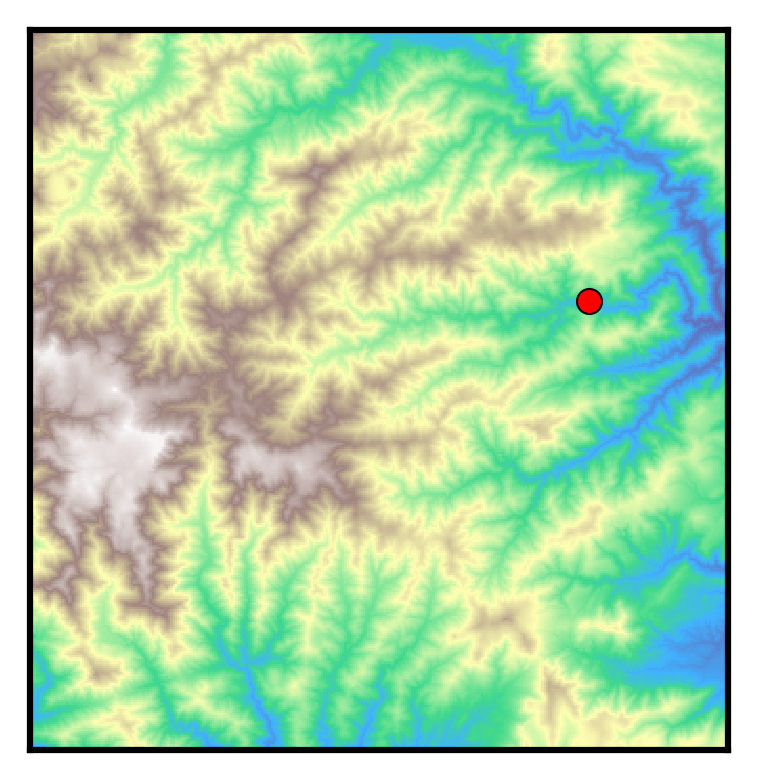

In [7]:
from rasterio.plot import show
from matplotlib_scalebar.scalebar import ScaleBar
dem_tmp = rasterio.open(dem_path)
bounds = dem_tmp.bounds
xlim = ([bounds[0], bounds[2]])
ylim = ([bounds[1], bounds[3]])

fig, ax = plt.subplots(1, 1, figsize=(3,3), dpi=300)
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)
ax.set(aspect='equal') 
scalebar = ScaleBar(1,box_alpha=0, scale_loc = 'top', location='lower left')
ax.imshow(np.ma.masked_where(dem_tmp.read(1) < -100,dem_tmp.read(1)), cmap='terrain')
show(np.ma.masked_where(dem_tmp.read(1) < -100, dem_tmp.read(1)), ax=ax, transform=dem_tmp.transform, 
         cmap='terrain', alpha=0.75, zorder=2, aspect="auto")
ax.plot(from_xyv[0],from_xyv[1],'ro')

##### Extraction du contour du bassin versant à partir du MNT et des coordonnées géographiques de l'exutoire

In [8]:
print('##### '+watershed_name.upper()+' #####')
BV = watershed_root.Watershed(dem_path=dem_path,
                              out_path=out_path,
                              load=load,
                              watershed_name=watershed_name,
                              from_lib=None, # os.path.join(root_dir,'watershed_library.csv')
                              from_dem=None, # [path, cell size]
                              from_shp=None, # [path, buffer size]
                              from_xyv=from_xyv, # [x, y, snap distance, buffer size]
                              #bottom_path=bottom_path, # path
                              #modflow_path=modflow_path, 
                              save_object=save_object)


##### GLUEYRE #####
      __  __          __           __  ____          ________     
     / / / /         / /          /  \/   /         / / __  /     
    / /_/ /_  ______/ /________  /       /___  ____/ / /_/ /_  __ 
   / __  / / / / __  / ___/ __ \/ /\,-/ / __ \/ __  / ____/ / / / 
  / / / / /_/ / /_/ / /  / /_/ / /   / / /_/ / /_/ / /   / /_/ /  
 /_/ /_/\__, /_____/_/   \____/_/   /_/\____/_____/_/____\__, /   
       /____/ Hydrological Modelling in Python /_____________/    
                                                                  
Object was not loaded as demanded, but created from scratch
Create new object, will removed previousy stored object
Extract geography of the model area
   Reshape tifs


#### Attributs de l'objet BV.geographic c'est à dire l'objet qui contient les informations géographiques du BV créé

In [9]:
print(dir(BV.geographic))
print(BV.geographic.area) #km2
print(BV.geographic.slope) #%

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', 'area', 'bottom_path', 'box_buff', 'buff_percent', 'cell_size', 'centroid', 'centroid_long_lat', 'centroid_long_lat_Greenwich', 'crs_proj', 'dem_box_data', 'dem_clip', 'dem_data', 'dem_path', 'dep_code', 'depressions', 'depressions_data', 'from_dem', 'from_lib', 'from_shp', 'from_xyv', 'geodata', 'gis_path', 'll_long_lat', 'lr_long_lat', 'model_from_dem', 'out_path', 'post_processing_dem', 'processing', 'reg_path', 'resolution', 'resolution_x', 'resolution_y', 'simulations_folder', 'slope', 'snap_dist', 'stable_folder', 'ul_long_lat', 'ur_long_lat', 'watershed', 'watershed_box_buff_dem', 'watershed_box_buff_direc', 'watershed_box_

#### Dessiner le Bassin Versant

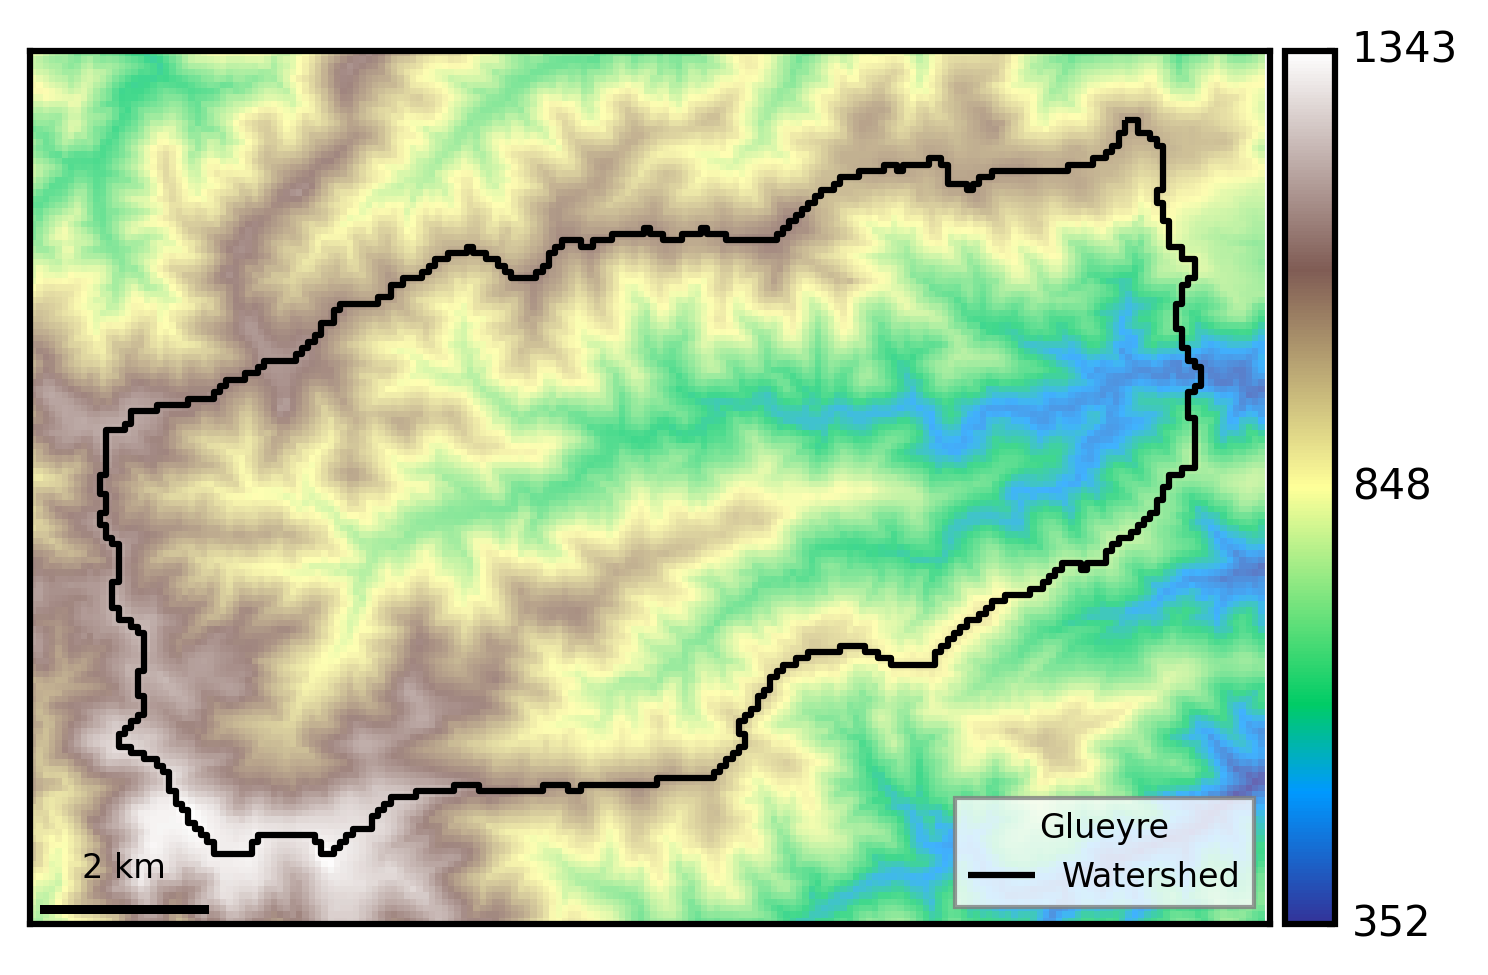

In [10]:
visualization_watershed.watershed_dem(BV)

**Quelle est la surface du Bassin Versant ? Sur quel type de relief/région se trouve-t-on? Vous pouvez utiliser les fichiers créés dans le dossier result_stable et Geographic et les mettre dans un logiciel de SIG pour mieux comprendre ou on est situé.**

 **D'après vous, comment hydromodpy a fait cette extraction de Bassin Versant?**

#### On ajoute la géologie et le réseau hydrographique à l'objet Bassin Versant créé

In [11]:
BV.add_geology(data_path, types_obs='GEO1M.shp', fields_obs='CODE_LEG')
BV.add_hydrography(data_path, types_obs=['cours_eau_V'], fields_obs=['fid'])
BV.add_hydrometry(data_path, 'france hydrometric stations.shp')

Extract geology from specific data
Extract hydrography from specific data
Extract hydrometry from specific data


#### Plot the watershed geology

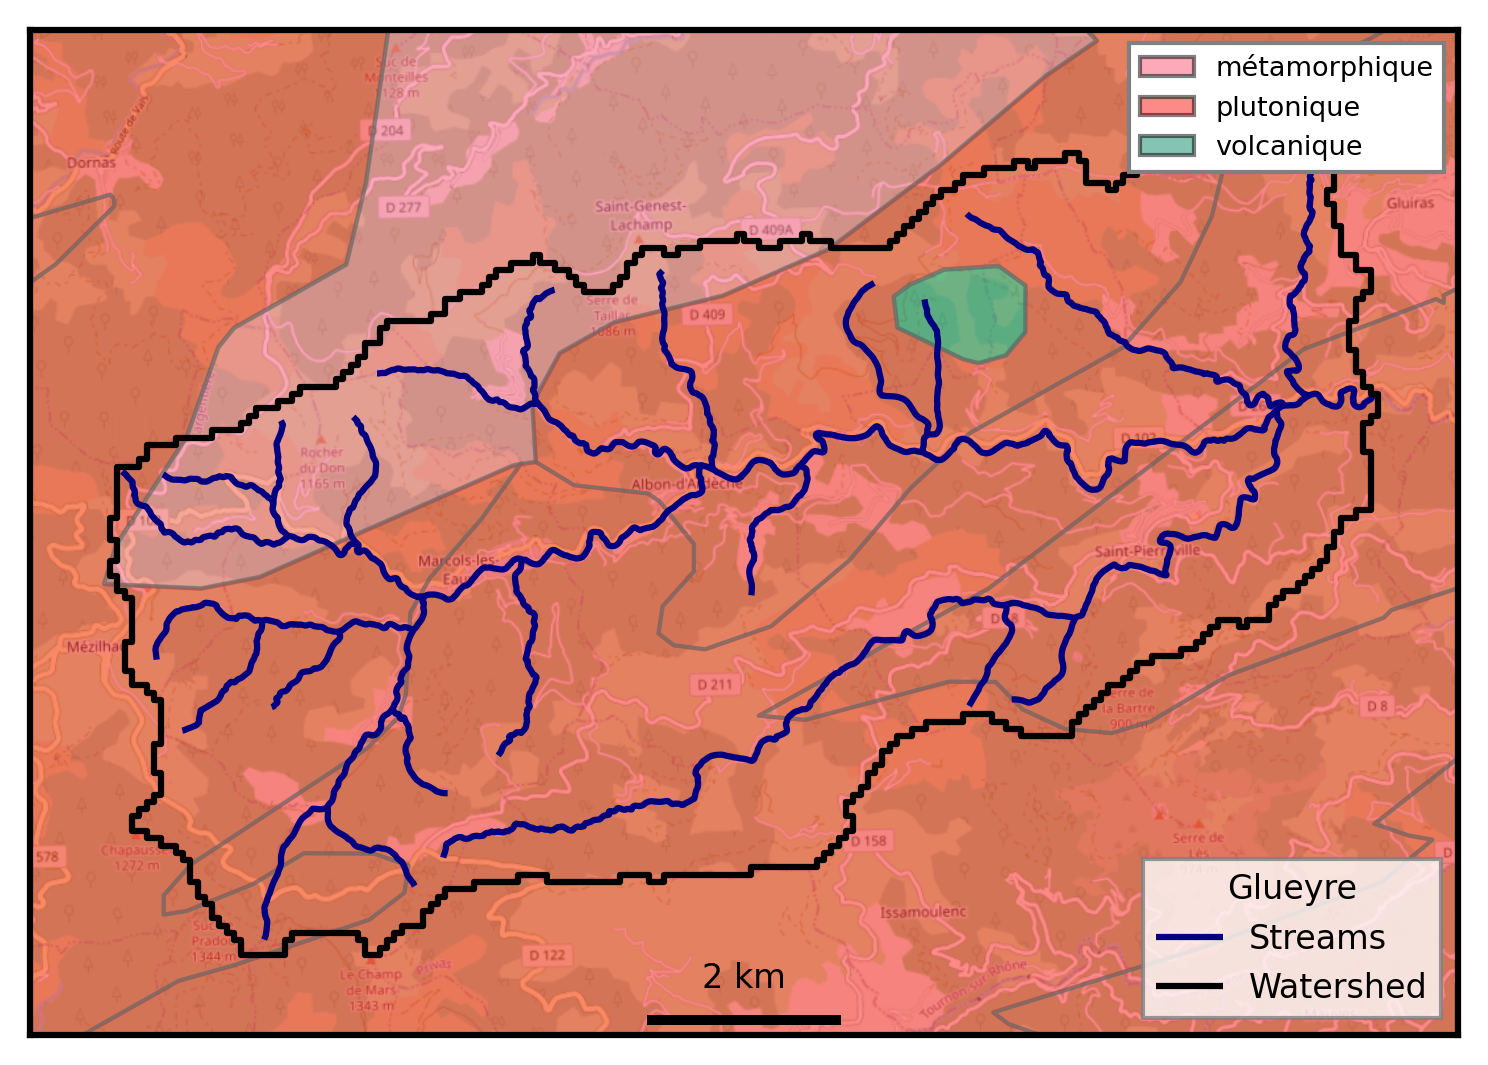

In [12]:
os.environ['PROJ_LIB'] = 'C:/Users/camil/anaconda3/envs/hydromodpy/Library/share/proj'
visualization_watershed.watershed_geology(BV)

**Descrire la géologie du bassin versant. Quelles sont les informations importantes pour une modélisation hydrogéologique?**

**De manière générale n'hésitez pas à utiliser les fichiers créés dans un logiciel de SIG si vous êtes plus à l'aise pour les figures.**